In [ ]:
!pip install pandas numpy scikit-learn joblib yfinance

In [1]:

import pandas as pd
import numpy as np

# Load CSV files
df1 = pd.read_csv('/content/drive/MyDrive/dataset1.csv')
df2 = pd.read_csv('/content/drive/MyDrive/dataset2.csv')

# Drop overlapping columns from df2 to avoid duplicate keys
df2_clean = df2.drop(columns=['Name', 'Price', 'Price/Earnings', 'Market Cap'], errors='ignore')

# Merge datasets on the ticker Symbol
df = pd.merge(df1, df2_clean, on='Symbol', how='inner')
print("Successfully merged dataset shape:", df.shape)

Successfully merged dataset shape: (200, 22)


In [2]:
df.head()

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,...,Price/Book,SEC Filings,Price(USD),Change,Change %,Volume_M,Avg_Vol_3m,Market_Cap_B,PE_Ratio,52_WK_Change %
0,MMM,3M Company,Industrials,222.89,24.31,2.332862,7.92,259.77,175.49,138721055226,...,11.34,http://www.sec.gov/cgi-bin/browse-edgar?action...,126.91,-12.83,-9.18,8.848,4.360,68.445,17.48,38.05
1,ABT,Abbott Laboratories,Health Care,56.27,22.51,1.908982,0.26,64.60,42.28,102121042306,...,3.19,http://www.sec.gov/cgi-bin/browse-edgar?action...,124.44,-7.19,-5.46,10.775,6.999,215.819,16.29,12.60
2,ABBV,AbbVie Inc.,Health Care,108.48,19.41,2.499560,3.29,125.86,60.05,181386347059,...,26.14,http://www.sec.gov/cgi-bin/browse-edgar?action...,186.96,-14.68,-7.28,11.141,6.688,330.729,78.23,10.11
3,AMD,Advanced Micro Devices Inc,Information Technology,11.22,187.00,0.000000,0.03,15.65,9.70,11191663795,...,21.47,http://www.sec.gov/cgi-bin/browse-edgar?action...,85.76,-8.04,-8.57,65.394,38.367,139.328,85.76,-49.52
4,AES,AES Corp,Utilities,10.06,9.96,4.961832,-1.72,12.05,10.00,6920851212,...,2.20,http://www.sec.gov/cgi-bin/browse-edgar?action...,10.78,-1.12,-9.41,19.553,15.603,7.674,4.55,-41.09


In [3]:
df.tail(10)

,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,...,Price/Book,SEC Filings,Price(USD),Change,Change %,Volume_M,Avg_Vol_3m,Market_Cap_B,PE_Ratio,52_WK_Change %
190,V,Visa Inc.,Information Technology,113.86,32.72,0.702048,2.80,126.88,84.8800,270038723213,...,9.40,http://www.sec.gov/cgi-bin/browse-edgar?action...,313.13,-26.26,-7.74,13.192,6.839,604.031,31.53,12.73
191,WMT,Wal-Mart Stores,Consumer Staples,100.02,23.10,1.983471,4.39,109.98,66.8900,304680931618,...,3.89,http://www.sec.gov/cgi-bin/browse-edgar?action...,83.19,-4.07,-4.66,36.160,21.241,666.922,34.52,39.16
192,WBA,Walgreens Boots Alliance,Consumer Staples,68.22,13.38,2.236824,3.78,88.00,63.8200,70862541911,...,3.06,http://www.sec.gov/cgi-bin/browse-edgar?action...,10.68,-0.38,-3.44,25.995,25.546,9.235,NaN,-44.26
193,WFC,Wells Fargo,Financials,55.40,13.58,2.711158,4.07,66.31,49.2700,281463620775,...,1.58,http://www.sec.gov/cgi-bin/browse-edgar?action...,60.98,-4.69,-7.14,31.015,16.496,199.109,11.36,5.52
194,WDC,Western Digital,Information Technology,80.09,10.19,2.389201,1.29,95.77,71.3800,24760297793,...,2.00,http://www.sec.gov/cgi-bin/browse-edgar?action...,30.54,-3.61,-10.57,22.909,8.993,10.623,8.83,-44.61
195,WU,Western Union Co,Information Technology,18.81,10.17,3.591585,0.51,22.21,18.3900,8951609207,...,12.65,http://www.sec.gov/cgi-bin/browse-edgar?action...,10.13,-0.37,-3.52,11.706,5.899,3.392,3.70,-24.85
196,WY,Weyerhaeuser Corp.,Real Estate,33.60,34.29,3.707995,0.77,37.89,30.9504,26070297960,...,2.90,http://www.sec.gov/cgi-bin/browse-edgar?action...,26.26,-1.17,-4.27,6.634,3.765,19.061,48.63,-23.71
197,WMB,Williams Cos.,Energy,28.56,48.41,4.000000,-0.57,33.67,26.8188,24802396470,...,3.01,http://www.sec.gov/cgi-bin/browse-edgar?action...,54.57,-4.46,-7.56,18.978,8.008,66.613,29.98,40.10
198,WYNN,Wynn Resorts Ltd,Consumer Discretionary,169.28,31.70,1.127904,7.27,203.63,92.6700,18225400525,...,51.69,http://www.sec.gov/cgi-bin/browse-edgar?action...,70.09,-2.79,-3.83,7.910,2.702,7.441,16.11,-33.87
199,XEL,Xcel Energy Inc,Utilities,42.44,18.14,3.391427,2.21,52.22,41.1600,21559611927,...,1.94,http://www.sec.gov/cgi-bin/browse-edgar?action...,67.89,-4.25,-5.89,5.367,3.704,39.006,19.74,25.54


In [4]:
# Drop non-numerical or trash columns
df = df.drop(columns=['SEC Filings', 'Name'], errors='ignore')

# Handle missing values by filling with 0
df = df.fillna(0)

# One-hot encode categorical columns like Sector
if 'Sector' in df.columns:
    df = pd.get_dummies(df, columns=['Sector'], drop_first=True)

# Note: If your CSVs don't contain pre-calculated target columns yet,
# you can define temporary mock target arrays for testing the pipeline script:
np.random.seed(42)
df['target_return'] = np.random.uniform(-10.0, 30.0, len(df))  # Expected Return %
df['risk_score_10'] = np.random.uniform(1.0, 10.0, len(df))  # Risk Score (1-10)

print("Data cleaned and ready for training!")

Data cleaned and ready for training!


In [5]:
df.shape

(200, 31)

In [6]:
df.head()

,Symbol,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,...,Sector_Financials,Sector_Health Care,Sector_Industrials,Sector_Information Technology,Sector_Materials,Sector_Real Estate,Sector_Telecommunication Services,Sector_Utilities,target_return,risk_score_10
0,MMM,222.89,24.31,2.332862,7.92,259.77,175.49,138721055226,9.048000e+09,4.390271,...,False,False,True,False,False,False,False,False,4.981605,6.778285
1,ABT,56.27,22.51,1.908982,0.26,64.60,42.28,102121042306,5.744000e+09,3.740480,...,False,True,False,False,False,False,False,False,28.028572,1.757260
2,ABBV,108.48,19.41,2.499560,3.29,125.86,60.05,181386347059,1.031000e+10,6.291571,...,False,True,False,False,False,False,False,False,19.279758,2.454658
3,AMD,11.22,187.00,0.000000,0.03,15.65,9.70,11191663795,3.390000e+08,2.109195,...,False,False,False,True,False,False,False,False,13.946339,9.086988
4,AES,10.06,9.96,4.961832,-1.72,12.05,10.00,6920851212,3.001000e+09,0.659514,...,False,False,False,False,False,False,False,True,-3.759254,6.457862


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

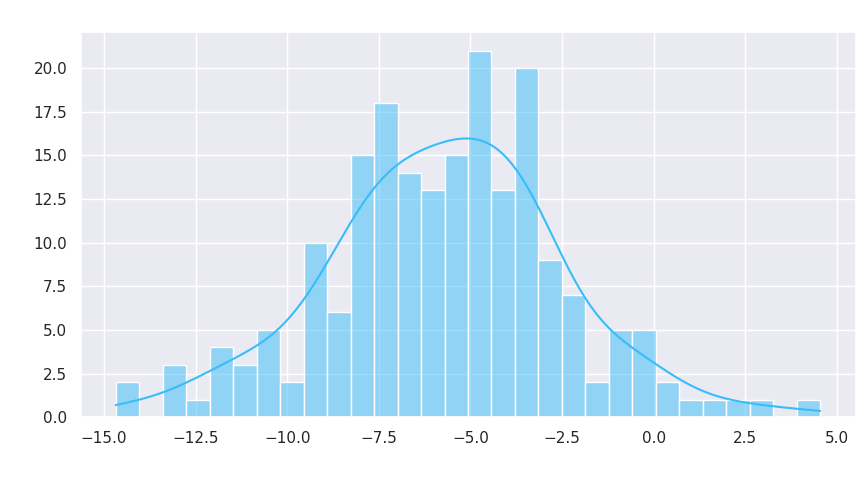

In [8]:
# 1. Distribution of Daily Price Change %
plt.figure()
sns.histplot(df['Change %'], kde=True, color='#38bdf8', bins=30)
plt.title('Distribution of Stock Change %', fontsize=12, fontweight='bold', color='white')
plt.xlabel('Change %', color='white')
plt.ylabel('Frequency', color='white')
plt.show()

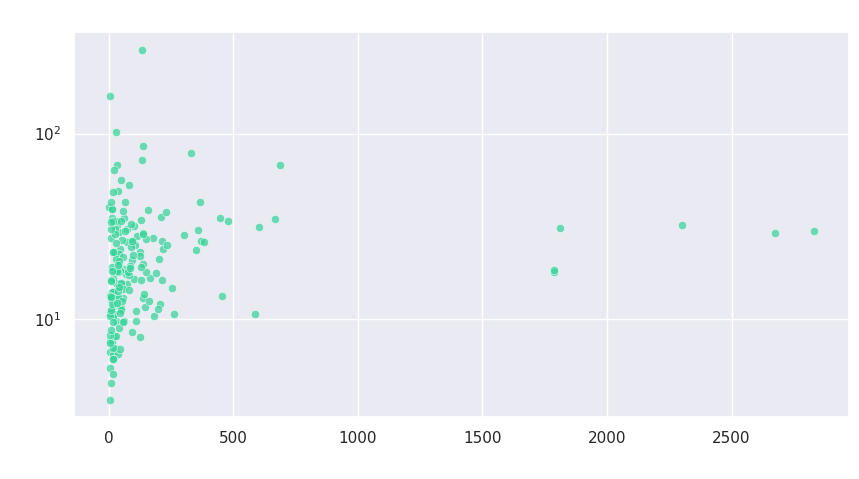

In [9]:
# 2. Market Cap vs. P/E Ratio Scatter Plot
plt.figure()
sns.scatterplot(data=df, x='Market_Cap_B', y='PE_Ratio', alpha=0.7, color='#34d399')
plt.title('Market Cap vs. P/E Ratio', fontsize=12, fontweight='bold', color='white')
plt.xlabel('Market Cap (Billion USD)', color='white')
plt.ylabel('P/E Ratio', color='white')
plt.yscale('log')  # Log scale handles extreme outliers in P/E and market cap
plt.show()

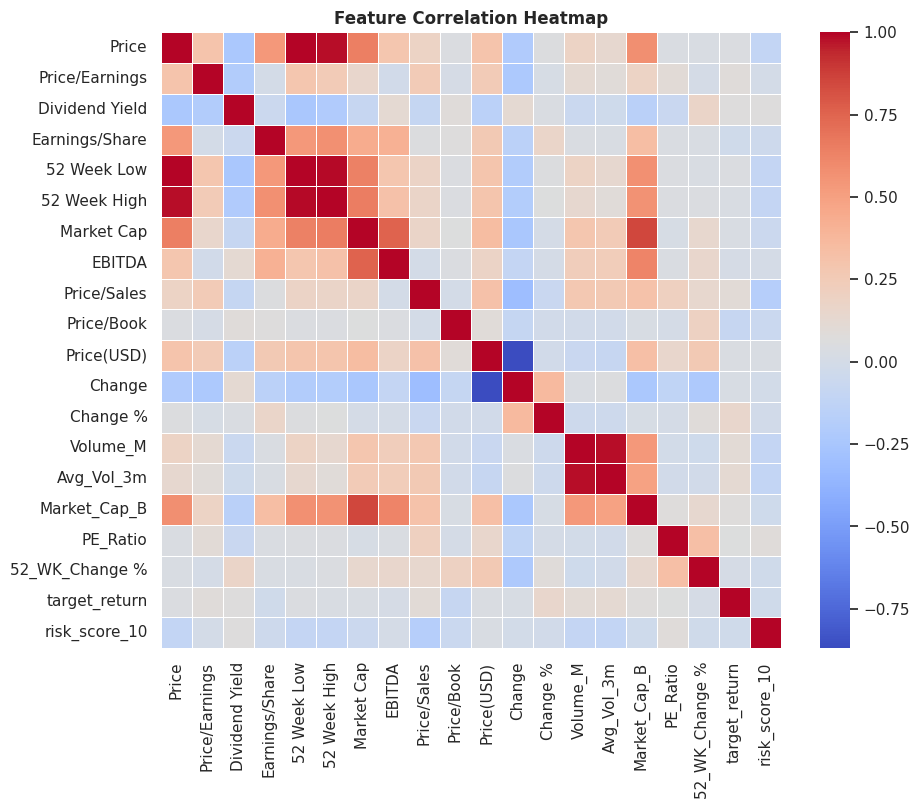

In [ ]:
# 3. Correlation Heatmap of Key Numerical Features
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')
plt.show()

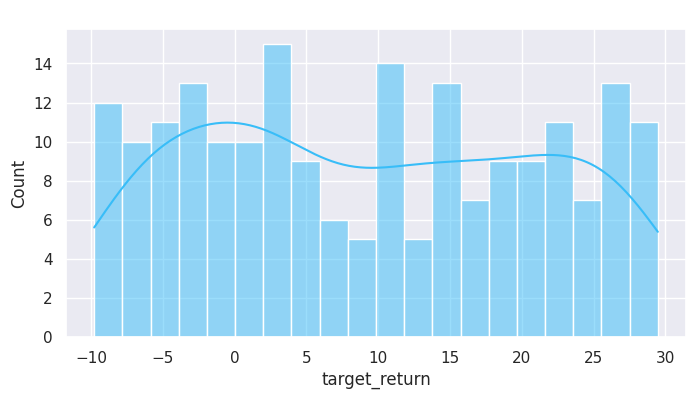

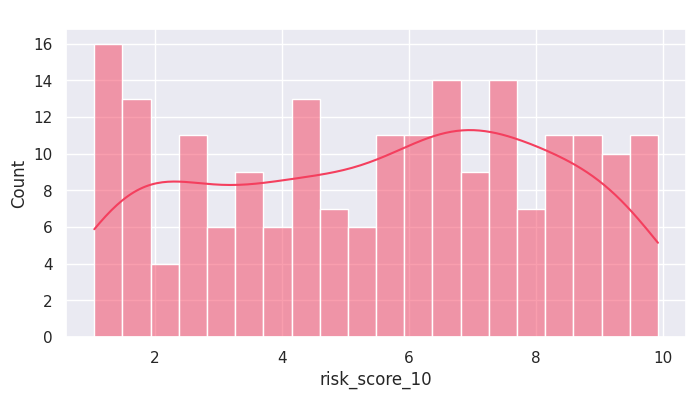

In [ ]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (8, 4)

# 1. Target Return Distribution
plt.figure()
sns.histplot(df['target_return'], kde=True, color='#38bdf8', bins=20)
plt.title('Distribution of Target Returns', color='white', fontsize=10)
plt.show()

# 2. Risk Score Distribution
plt.figure()
sns.histplot(df['risk_score_10'], kde=True, color='#f43f5e', bins=20)
plt.title('Distribution of Risk Scores (1-10)', color='white', fontsize=10)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import os

# Separate features and targets
drop_cols = ['Symbol', 'Name', 'target_return', 'risk_score_10']
X = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')
X = X.select_dtypes(include=['number'])

y_return = df['target_return']
y_risk = df['risk_score_10']

# Split data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_return, test_size=0.2, random_state=42)
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X, y_risk, test_size=0.2, random_state=42)

# Train models
return_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
return_regressor.fit(X_train_r, y_train_r)

risk_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
risk_regressor.fit(X_train_k, y_train_k)

# Evaluation
print(f"Return Regressor MAE: {mean_absolute_error(y_test_r, return_regressor.predict(X_test_r)):.4f}")
print(f"Risk Regressor MAE: {mean_absolute_error(y_test_k, risk_regressor.predict(X_test_k)):.4f}")

Return Regressor MAE: 10.9424
Risk Regressor MAE: 1.9991


In [11]:
os.makedirs('artifacts', exist_ok=True)
joblib.dump(return_regressor, 'artifacts/return_regressor.pkl')
joblib.dump(risk_regressor, 'artifacts/risk_score_regressor.pkl')

#

['artifacts/risk_score_regressor.pkl']